# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Maria Reina Zarate Nava

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
import seaborn as sns

In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
#Cargar el dataset
dfventas = pd.read_csv("ventas-por-factura.csv")

In [10]:
#Mostrar las primeras filas
dfventas.head(5)

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [12]:
#Dimensiones del dataset
dfventas.shape

(25953, 6)

In [14]:
dfventas.tail()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"
25952,537999,12/9/2020 11:44:00,NaN,United Kingdom,-223,"0,00"


In [16]:
dfventas.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [19]:
#Generamos una copia por cualquier cosa
dfventas = dfventas.copy()

In [21]:
dfventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  str    
 1   Fecha de factura  25953 non-null  str    
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  str    
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.2 MB


<function matplotlib.pyplot.show(close=None, block=None)>

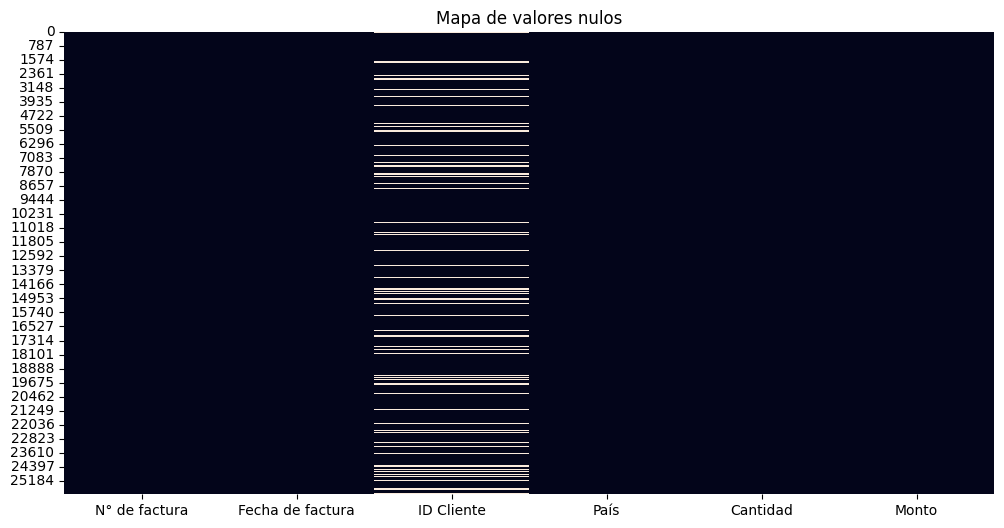

In [22]:
#Identificamos valores nulos
plt.figure(figsize = (12, 6))
sns.heatmap(dfventas.isnull(), cbar = False)
plt.title("Mapa de valores nulos")
plt.show

In [23]:
dfventas.isnull().sum()

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64

In [63]:
dfventas["ID Cliente"] = dfventas["ID Cliente"].fillna("ID Cliente")

In [64]:
dfventas.isnull().sum()

N° de factura           0
Fecha de factura        0
ID Cliente              0
País                    0
Cantidad                0
Monto               25943
dtype: int64

In [65]:
dfventas["Monto"] = dfventas["Monto"].fillna("Monto")

In [66]:
dfventas.isnull().sum()

N° de factura       0
Fecha de factura    0
ID Cliente          0
País                0
Cantidad            0
Monto               0
dtype: int64

In [40]:
#Identificar los Outliers (Negativos o fuera de rango)
outliers_negativos = dfventas[(dfventas["Cantidad"] < 0) | (dfventas["Monto"] < 0)]

In [41]:
outliers_negativos

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,NaN
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,NaN
16,542418,1/27/2021 17:39:00,NaN,United Kingdom,-17,NaN
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,NaN
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,NaN
...,...,...,...,...,...,...
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,NaN
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,NaN
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,NaN
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,NaN


In [42]:
#Identificar los Outliers (Negativos o fuera de rango)
outliers_rango = dfventas[(dfventas["Cantidad"] > 1000) | (dfventas["Monto"] > 100000)]

In [43]:
outliers_rango

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
12,537823,12/8/2020 14:25:00,NaN,United Kingdom,1484,NaN
27,576083,11/14/2021 8:22:00,17404.0,Sweden,1060,NaN
67,577783,11/21/2021 16:20:00,18139.0,United Kingdom,1644,NaN
143,547419,3/23/2021 10:27:00,15061.0,United Kingdom,1135,NaN
167,569740,10/6/2021 10:52:00,15769.0,United Kingdom,1600,NaN
...,...,...,...,...,...,...
25828,541423,1/17/2021 17:54:00,NaN,United Kingdom,1230,NaN
25877,572209,10/21/2021 12:08:00,18102.0,United Kingdom,1920,NaN
25914,561647,7/28/2021 15:20:00,13340.0,United Kingdom,1764,NaN
25917,559052,7/5/2021 16:53:00,NaN,United Kingdom,1562,NaN


In [35]:
#Convierte la columna Monto a numéricas y Detectar problemas en Monto
dfventas["Monto"] = pd.to_numeric(dfventas["Monto"], errors="coerce")

In [67]:
invalidos_monto = dfventas[dfventas["Monto"].isnull()]

In [68]:
invalidos_monto

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto


In [57]:
#Detectar problemas en Fecha de factura
dfventas["Fecha de factura"] = pd.to_datetime(dfventas["Fecha de factura"], errors="coerce")

In [69]:
invalidos_fecha = dfventas[dfventas["Fecha de factura"].isnull()]

In [70]:
invalidos_fecha

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto


In [44]:
#Identificar valores negativos
invalidos_negativos = dfventas[(dfventas["Cantidad"] < 0) | (dfventas["Monto"] < 0)]

In [45]:
invalidos_negativos

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,NaN
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,NaN
16,542418,1/27/2021 17:39:00,NaN,United Kingdom,-17,NaN
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,NaN
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,NaN
...,...,...,...,...,...,...
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,NaN
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,NaN
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,NaN
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,NaN


In [46]:
#Identificar valores nulos
invalidos_nulos = dfventas[dfventas["Cantidad"].isnull() | dfventas["Monto"].isnull()]

In [47]:
invalidos_nulos

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,NaN
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,NaN
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,NaN
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,NaN
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,NaN
...,...,...,...,...,...,...
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,NaN
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,NaN
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,NaN
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,NaN


In [48]:
facturas_canceladas = dfventas[dfventas["N° de factura"].str.contains("C", na=False)]

In [49]:
facturas_canceladas

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,NaN
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,NaN
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,NaN
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,NaN
22,C547309,3/22/2021 11:17:00,17416.0,United Kingdom,-12,NaN
...,...,...,...,...,...,...
25939,C572450,10/24/2021 12:35:00,NaN,United Kingdom,-2,NaN
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,NaN
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,NaN
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,NaN


In [26]:
#Contar cuántas filas duplicadas hay
dfventas.duplicated().sum()

np.int64(0)

In [25]:
#Eliminar todas las filas duplicadas
dfventas.drop_duplicates(inplace=True)

In [30]:
dfventas.columns

Index(['N° de factura', 'Fecha de factura', 'ID Cliente', 'País', 'Cantidad',
       'Monto'],
      dtype='str')

In [58]:
dfventas.dtypes

N° de factura                  str
Fecha de factura    datetime64[us]
ID Cliente                 float64
País                           str
Cantidad                     int64
Monto                      float64
dtype: object

In [71]:
dfventas["Monto"] = pd.to_numeric(dfventas["Monto"], errors="coerce")

In [72]:
#Detectar problemas en Monto
invalidos_monto = dfventas[dfventas["Monto"].isnull()]

In [73]:
invalidos_monto

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,2021-03-30 16:14:00,15528.0,United Kingdom,123,NaN
1,575767,2021-11-11 11:11:00,17348.0,United Kingdom,163,NaN
2,C570727,2021-10-12 11:32:00,12471.0,Germany,-1,NaN
3,549106,2021-04-06 12:08:00,17045.0,United Kingdom,1,NaN
4,573112,2021-10-27 15:33:00,16416.0,United Kingdom,357,NaN
...,...,...,...,...,...,...
25948,C556518,2021-06-13 10:53:00,16794.0,United Kingdom,-2,NaN
25949,553060,2021-05-13 10:44:00,15826.0,United Kingdom,488,NaN
25950,577049,2021-11-17 13:58:00,17397.0,United Kingdom,104,NaN
25951,550122,2021-04-14 12:39:00,12931.0,United Kingdom,1176,NaN


In [60]:
#Detectar problemas en Fecha de factura
dfventas["Fecha de factura"] = pd.to_datetime(dfventas["Fecha de factura"], errors="coerce")

In [61]:
invalidos_fecha = dfventas[dfventas["Fecha de factura"].isnull()]

In [62]:
invalidos_fecha

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto


In [56]:
dfventas.info()

<class 'pandas.DataFrame'>
Index: 25943 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   N° de factura     25943 non-null  str           
 1   Fecha de factura  25943 non-null  datetime64[us]
 2   ID Cliente        22221 non-null  float64       
 3   País              25943 non-null  str           
 4   Cantidad          25943 non-null  int64         
 5   Monto             0 non-null      float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 1.4 MB


In [ ]:
# Justificación de mis desiciones tomadas
Limpie y transforme los datos. La limpieza incluyó eliminar duplicados, detectar y manejar valores nulos, convertir columnas al tipo de dato correcto (por ejemplo, facturas y montos a numérico, fechas a formato datetime), y filtrar registros inválidos como cantidades negativas o facturas canceladas. La transformación consistió en dejar las columnas listas para análisis, con formatos homogéneos y sin inconsistencias. Estas decisiones se justifican porque un dataset sucio genera resultados poco confiables y puede afectar cualquier análisis posterior.

#Explicación de cómo afecta el principio GIGO al análisis de datos y Machine Learning
El principio GIGO (Garbage In, Garbage Out) explica justamente esto: si los datos de entrada son incorrectos o están mal formateados, los resultados del análisis o de un modelo de Machine Learning también serán erróneos. No importa qué tan sofisticado sea el algoritmo, si se alimenta con datos basura, lo que se obtiene es basura. Por eso es tan importante dedicar tiempo a limpiar y transformar los datos antes de analizarlos o entrenar un modelo.